## MNIST Fashion Dataset - Item Prediction

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's see the length of training and testing sets:

In [ ]:
len(X_train), len(X_test)

(60000, 10000)

How about the resolution of the photos and the visualisation of one?

Resolution of photos (height, width): (28, 28)


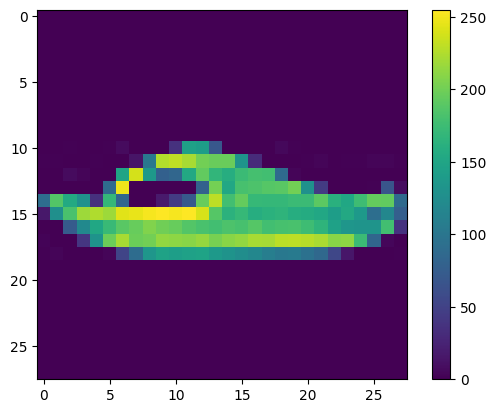

The visualized item is a: Sandal (label: 5)


In [ ]:
print(f"Resolution of photos (height, width): {X_train.shape[1:]}")

import random; image_index = random.randint(0, len(X_train))
plt.imshow(X_train[image_index])
plt.colorbar()
plt.grid(False)
plt.show()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
item_label = y_train[image_index]
item_name = class_names[item_label]
print(f"The visualized item is a: {item_name} (label: {item_label})")

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
# We do not want three-dimensional array. Instead, we need to reduce dimensionality.

X_train, X_test = X_train.reshape(len(X_train), 28*28), X_test.reshape(len(X_test), 28*28)
print("Shape of the flattened training set:", X_train.shape)
print("Shape of the flattened testing set:", X_test.shape)

Shape of the flattened training set: (60000, 784)
Shape of the flattened testing set: (10000, 784)


In [ ]:
# Let's wrap tf.keras to just "keras":
from tensorflow import keras

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1538 - loss: 22.2389
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1755 - loss: 12.0645
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1767 - loss: 11.3844
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1836 - loss: 10.4680
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1729 - loss: 9.9641
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1709 - loss: 10.0134
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1625 - loss: 10.4168
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1696 - loss: 10.0821
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1702 - loss: 9.6682
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1670 - loss: 9.2597


These numbers for accuracy score are extremely low.

I presume that the problem is data normalisation.

In [ ]:
X_train, X_test = X_train/255, X_test/255

Now let's run again:

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7427 - loss: 0.7771
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8411 - loss: 0.4666
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8507 - loss: 0.4393
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8578 - loss: 0.4155
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8581 - loss: 0.4079


In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8431 - loss: 0.4444


[0.45598822832107544, 0.8396999835968018]

Let's test a specific one.

In [ ]:
# First: assigning the predicted set
predicted_set = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


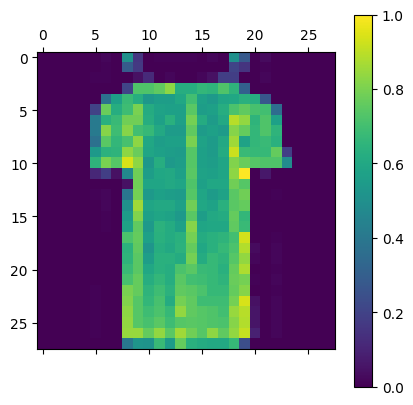

In [ ]:
# Second: printing a random one
import random; random_num = random.randint(0, len(X_test))

plt.matshow(X_test[random_num].reshape(28, 28))
plt.colorbar(); plt.show()

In [ ]:
predicted_set[random_num]

array([9.8602802e-01, 4.2471793e-03, 1.3044278e-01, 5.2888441e-01,
       2.2528682e-02, 4.4663015e-12, 9.1531157e-01, 4.1999990e-10,
       2.0946989e-02, 1.9578819e-08], dtype=float32)

It prints a NumPy array which we fairly do not understand anything.

**Solution**: `np.argmax`

In [ ]:
predicted_label = np.argmax(predicted_set[random_num])

## But before that:

We need to initialise the class names in order to understand which exact item it will be.

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

**Now:**

In [ ]:
predicted_item_name = class_names[predicted_label]
print(f"The model predicts this item is a: {predicted_item_name} (label: {predicted_label})")

The model predicts this item is a: T-shirt/top (label: 0)


However, only one item is printed. What we need to do is to ensure that even the first 15 (or 20, it can be adjusted) are being correctly predicted.

In [47]:
predicted_labels = [int(np.argmax(i)) for i in predicted_set]
print("The predicted labels of the first 15:", predicted_labels[:15])
print("The actual labels of the first 15:   ", list([int(i) for i in y_test[:15]]))

The predicted labels of the first 15: [9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4]
The actual labels of the first 15:    [9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4]


## Almost perfect.
![alt_img](https://i1.sndcdn.com/artworks-tCLQZAMS5G99Yyhd-ZpIUVQ-t500x500.jpg)

Now there comes up the confusion matrix:

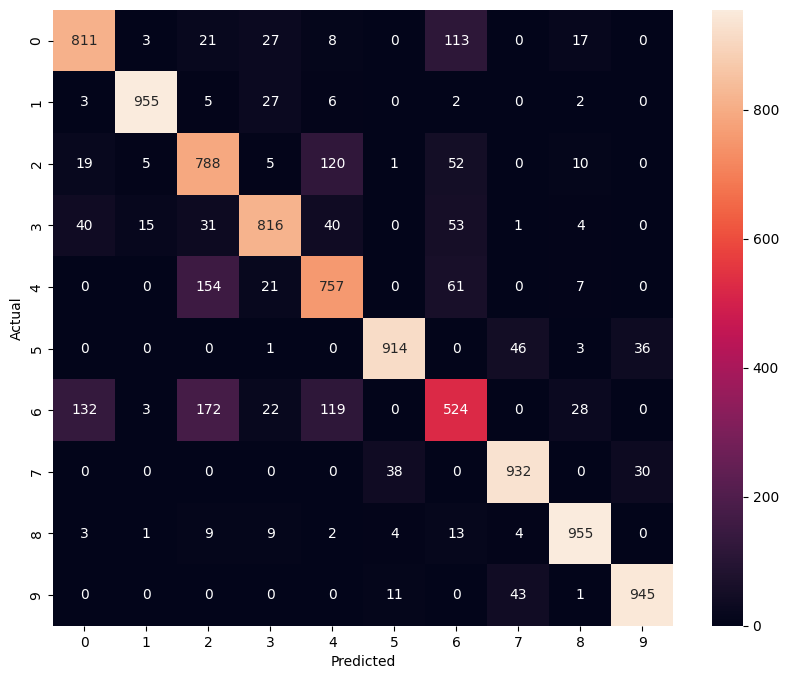

In [49]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=predicted_labels)

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Summary of the confusion matrix is that the results in the diagonal are slightly above the average except 6 which got 524/1000 (way below the average). Also, the results of some cells such as `2, 6` are terrible.

In order to reduce it:


In [57]:
model = keras.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=(784,)),
    keras.layers.Dense(10, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7757 - loss: 0.6497
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8595 - loss: 0.3902
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8774 - loss: 0.3411
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8846 - loss: 0.3194
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8879 - loss: 0.3002


In [58]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8783 - loss: 0.3401


[0.34585604071617126, 0.8773999810218811]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


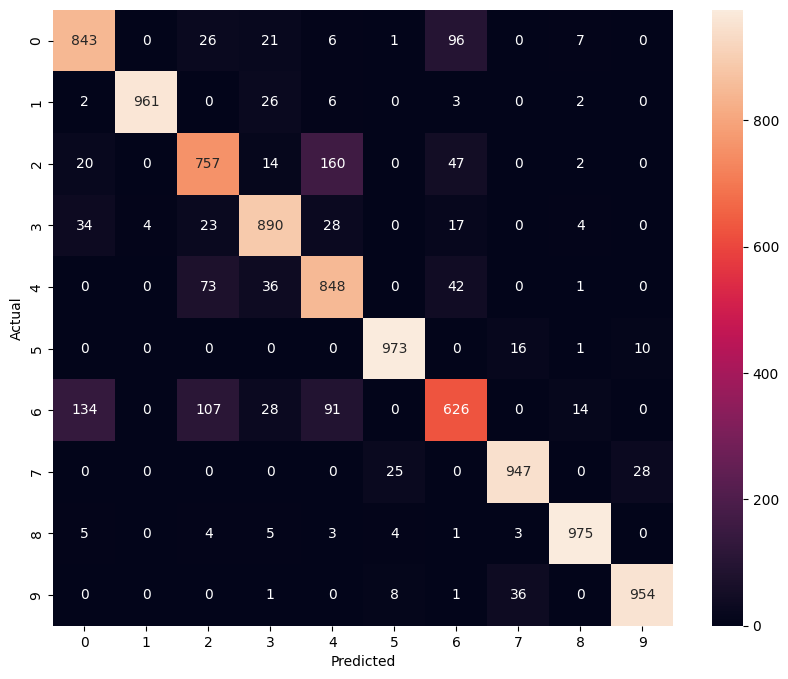

In [59]:
predicted_set = model.predict(X_test)
predicted_labels = [int(np.argmax(i)) for i in predicted_set]
cm = tf.math.confusion_matrix(labels=y_test, predictions=predicted_labels)

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Last option:
### Subtask:
We'll the model definition to change the activation function of the output `Dense` layer from `sigmoid` to `softmax`.


In [60]:
model = keras.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=(784,)),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7735 - loss: 0.6452
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8631 - loss: 0.3832
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8756 - loss: 0.3454
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8831 - loss: 0.3187
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8874 - loss: 0.3045


In [61]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8689 - loss: 0.3545


[0.3557727336883545, 0.871399998664856]

In [62]:
predicted_set = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


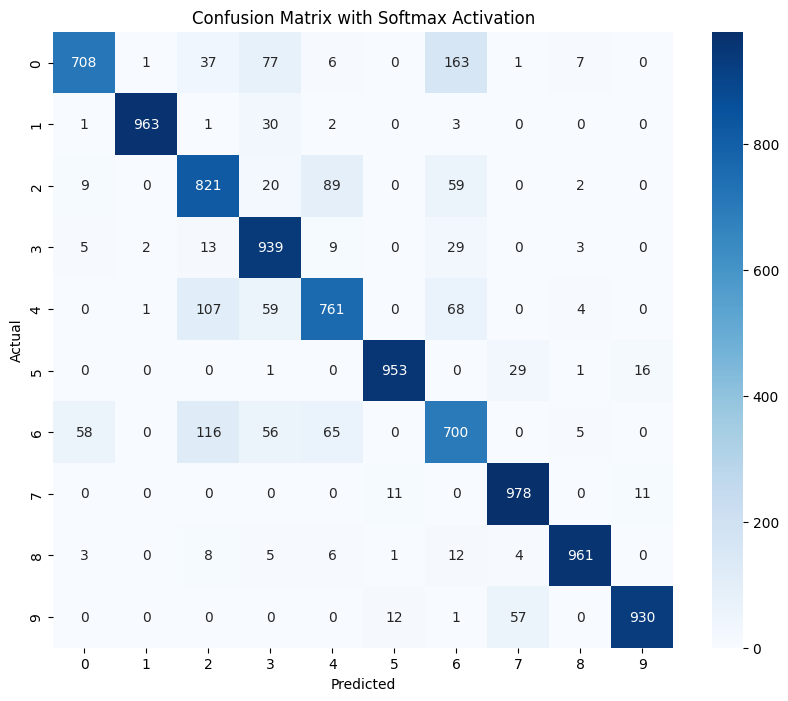

In [63]:
predicted_labels = [int(np.argmax(i)) for i in predicted_set]

cm = tf.math.confusion_matrix(labels=y_test, predictions=predicted_labels)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Softmax Activation")
plt.show()

## Great.

In [64]:
print("Confusion Matrix:\n", cm.numpy())

Confusion Matrix:
 [[708   1  37  77   6   0 163   1   7   0]
 [  1 963   1  30   2   0   3   0   0   0]
 [  9   0 821  20  89   0  59   0   2   0]
 [  5   2  13 939   9   0  29   0   3   0]
 [  0   1 107  59 761   0  68   0   4   0]
 [  0   0   0   1   0 953   0  29   1  16]
 [ 58   0 116  56  65   0 700   0   5   0]
 [  0   0   0   0   0  11   0 978   0  11]
 [  3   0   8   5   6   1  12   4 961   0]
 [  0   0   0   0   0  12   1  57   0 930]]


## Gratitude for your attention!

![alt_img](https://static0.srcdn.com/wordpress/wp-content/uploads/2020/07/Robert-Downey-Jr-as-Tony-Stark-Peace-Sign.jpg?q=50&fit=crop&w=1008&h=693&dpr=1.5)